# Model Training and Evaluation

This notebook trains and evaluates the machine learning models used in the
fetal health classification study.

The processed training and testing datasets contain the 10 selected features
obtained during feature selection and standardized using `StandardScaler`.

The following models are implemented:

1. Multi-Layer Perceptron (MLP)
2. Gradient Boosting
3. XGBoost
4. LightGBM
5. Linear Support Vector Machine (Linear SVM)

Model performance is evaluated using accuracy, precision, recall,
F1-score, and confusion matrices.

In [ ]:
!pip install -q xgboost lightgbm

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Load Processed Data

The processed training and testing datasets generated in the previous
notebook are loaded directly.

The datasets already contain the 10 selected and standardized features,
so no additional feature selection or scaling is required here.

In [ ]:
TRAIN_PATH = "/content/fetal_health_train_processed.csv"
TEST_PATH = "/content/fetal_health_test_processed.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape :", test_df.shape)

train_df.head()

Training dataset shape: (1479, 11)
Testing dataset shape : (634, 11)


,baseline value,accelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,histogram_mode,histogram_mean,histogram_median,histogram_variance,fetal_health
0,-1.140907,0.200165,-0.277999,-1.502090,0.408071,-0.546242,-0.279865,-0.880054,-0.838696,0.461035,1
1,-1.844535,-0.055486,-0.277999,-1.502090,0.408071,-0.546242,-0.524391,-0.815968,-0.907597,0.001934,1
2,1.472570,0.455817,-0.277999,-1.154758,0.183999,-0.111365,1.187289,1.234806,1.297246,-0.457166,1
3,0.065313,-0.311138,-0.277999,-1.212647,0.520106,-0.002646,0.575974,-0.111014,-0.080781,0.743558,1
4,-0.336760,0.711468,1.386621,-1.617867,1.080285,-0.546242,-0.218734,-0.495534,-0.356386,0.849504,1


In [ ]:
X_train = train_df.drop(columns=["fetal_health"])
y_train = train_df["fetal_health"].astype(int)

X_test = test_df.drop(columns=["fetal_health"])
y_test = test_df["fetal_health"].astype(int)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

X_train: (1479, 10)
y_train: (1479,)
X_test : (634, 10)
y_test : (634,)

Training class distribution:
fetal_health
1    1149
2     202
3     128
Name: count, dtype: int64

Testing class distribution:
fetal_health
1    497
2     90
3     47
Name: count, dtype: int64


In [ ]:
results = []
predictions = {}
trained_models = {}

## Multi-Layer Perceptron

A Multi-Layer Perceptron is a feed-forward neural network capable of
learning nonlinear relationships between the cardiotocography features
and fetal health classes.

In [ ]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=2000,
    random_state=42
)

mlp_model.fit(X_train, y_train)

mlp_pred = mlp_model.predict(X_test)

mlp_accuracy = accuracy_score(
    y_test,
    mlp_pred
)

print("MLP Accuracy:", round(mlp_accuracy, 6))

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        mlp_pred,
        labels=[1, 2, 3],
        target_names=[
            "Normal",
            "Suspect",
            "Pathological"
        ],
        digits=4
    )
)

results.append({
    "Model": "Multi-Layer Perceptron",
    "Accuracy": mlp_accuracy
})

predictions["Multi-Layer Perceptron"] = mlp_pred
trained_models["Multi-Layer Perceptron"] = mlp_model

MLP Accuracy: 0.949527

Classification Report:

              precision    recall  f1-score   support

      Normal     0.9662    0.9779    0.9720       497
     Suspect     0.8675    0.8000    0.8324        90
Pathological     0.9167    0.9362    0.9263        47

    accuracy                         0.9495       634
   macro avg     0.9168    0.9047    0.9102       634
weighted avg     0.9485    0.9495    0.9488       634



## Gradient Boosting

Gradient Boosting builds a sequence of weak decision-tree models, where
each new model attempts to correct errors made by the previous models.

In [ ]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_accuracy = accuracy_score(
    y_test,
    gb_pred
)

print(
    "Gradient Boosting Accuracy:",
    round(gb_accuracy, 6)
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        gb_pred,
        labels=[1, 2, 3],
        target_names=[
            "Normal",
            "Suspect",
            "Pathological"
        ],
        digits=4
    )
)

results.append({
    "Model": "Gradient Boosting",
    "Accuracy": gb_accuracy
})

predictions["Gradient Boosting"] = gb_pred
trained_models["Gradient Boosting"] = gb_model

Gradient Boosting Accuracy: 0.955836

Classification Report:

              precision    recall  f1-score   support

      Normal     0.9683    0.9839    0.9760       497
     Suspect     0.9000    0.8000    0.8471        90
Pathological     0.9184    0.9574    0.9375        47

    accuracy                         0.9558       634
   macro avg     0.9289    0.9138    0.9202       634
weighted avg     0.9549    0.9558    0.9549       634



## XGBoost

XGBoost is a gradient-boosted decision-tree algorithm designed for
efficient and accurate supervised learning.

Because XGBoost expects class labels beginning from zero, the original
target values (1, 2, 3) are temporarily converted to (0, 1, 2) during
training and converted back after prediction.

In [ ]:
# Convert labels:
# 1 -> 0
# 2 -> 1
# 3 -> 2

y_train_xgb = y_train - 1

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train_xgb
)

# XGBoost returns 0, 1, 2
xgb_pred_zero = xgb_model.predict(X_test)

# Convert back to 1, 2, 3
xgb_pred = xgb_pred_zero + 1

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print(
    "XGBoost Accuracy:",
    round(xgb_accuracy, 6)
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        xgb_pred,
        labels=[1, 2, 3],
        target_names=[
            "Normal",
            "Suspect",
            "Pathological"
        ],
        digits=4
    )
)

results.append({
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy
})

predictions["XGBoost"] = xgb_pred
trained_models["XGBoost"] = xgb_model

XGBoost Accuracy: 0.955836

Classification Report:

              precision    recall  f1-score   support

      Normal     0.9665    0.9859    0.9761       497
     Suspect     0.8987    0.7889    0.8402        90
Pathological     0.9375    0.9574    0.9474        47

    accuracy                         0.9558       634
   macro avg     0.9342    0.9108    0.9212       634
weighted avg     0.9547    0.9558    0.9547       634



## LightGBM

LightGBM is a gradient-boosting framework based on decision trees and is
one of the models evaluated in the reference paper.

In [ ]:
lgbm_model = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

lgbm_model.fit(
    X_train,
    y_train
)

lgbm_pred = lgbm_model.predict(
    X_test
)

lgbm_accuracy = accuracy_score(
    y_test,
    lgbm_pred
)

print(
    "LightGBM Accuracy:",
    round(lgbm_accuracy, 6)
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        lgbm_pred,
        labels=[1, 2, 3],
        target_names=[
            "Normal",
            "Suspect",
            "Pathological"
        ],
        digits=4
    )
)

results.append({
    "Model": "LightGBM",
    "Accuracy": lgbm_accuracy
})

predictions["LightGBM"] = lgbm_pred
trained_models["LightGBM"] = lgbm_model

LightGBM Accuracy: 0.958991

Classification Report:

              precision    recall  f1-score   support

      Normal     0.9666    0.9899    0.9781       497
     Suspect     0.9467    0.7889    0.8606        90
Pathological     0.9000    0.9574    0.9278        47

    accuracy                         0.9590       634
   macro avg     0.9378    0.9121    0.9222       634
weighted avg     0.9588    0.9590    0.9577       634



## Linear Support Vector Machine

Linear SVM attempts to separate the fetal health classes using linear
decision boundaries.

The standardized features produced in the previous notebook are
particularly useful for SVM-based models because their performance can
be affected by differences in feature scale.

In [ ]:
linear_svm_model = LinearSVC(
    random_state=42,
    max_iter=10000
)

linear_svm_model.fit(
    X_train,
    y_train
)

linear_svm_pred = linear_svm_model.predict(
    X_test
)

linear_svm_accuracy = accuracy_score(
    y_test,
    linear_svm_pred
)

print(
    "Linear SVM Accuracy:",
    round(linear_svm_accuracy, 6)
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        linear_svm_pred,
        labels=[1, 2, 3],
        target_names=[
            "Normal",
            "Suspect",
            "Pathological"
        ],
        digits=4
    )
)

results.append({
    "Model": "Linear Support Vector",
    "Accuracy": linear_svm_accuracy
})

predictions["Linear Support Vector"] = linear_svm_pred
trained_models["Linear Support Vector"] = linear_svm_model

Linear SVM Accuracy: 0.892744

Classification Report:

              precision    recall  f1-score   support

      Normal     0.9162    0.9678    0.9413       497
     Suspect     0.7273    0.5333    0.6154        90
Pathological     0.8605    0.7872    0.8222        47

    accuracy                         0.8927       634
   macro avg     0.8346    0.7628    0.7930       634
weighted avg     0.8852    0.8927    0.8862       634



## Model Performance Comparison

The test-set accuracy of each classifier is compared to examine how the
different machine learning approaches perform on the same dataset.

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df["Accuracy (%)"] = (
    results_df["Accuracy"] * 100
).round(2)

results_df

,Model,Accuracy,Accuracy (%)
0,LightGBM,0.958991,95.90
1,XGBoost,0.955836,95.58
2,Gradient Boosting,0.955836,95.58
3,Multi-Layer Perceptron,0.949527,94.95
4,Linear Support Vector,0.892744,89.27


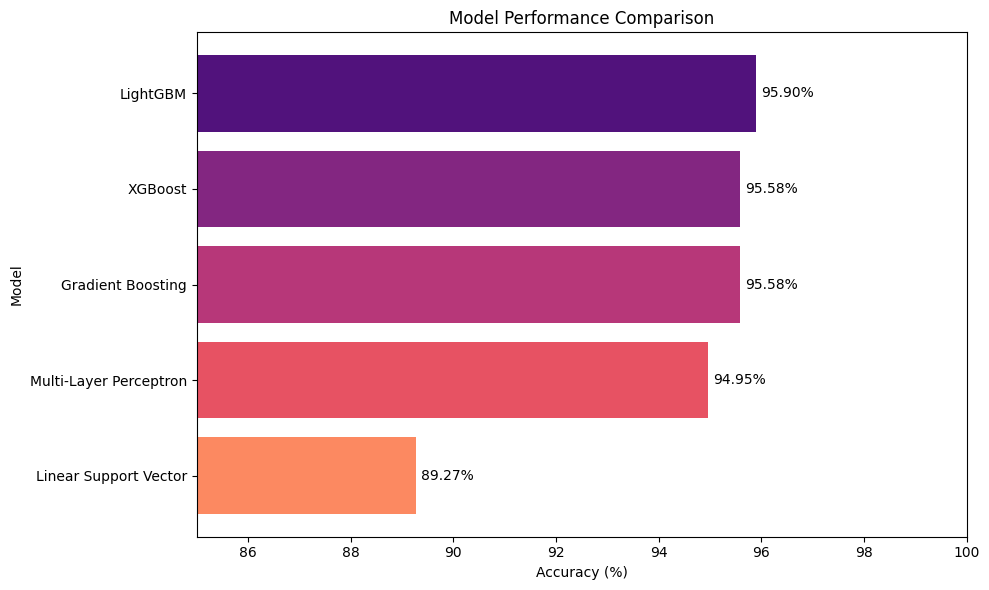

In [ ]:
plot_results = results_df.sort_values(
    "Accuracy",
    ascending=True
).copy()

colors = plt.cm.magma(
    np.linspace(0.75, 0.25, len(plot_results))
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_results["Model"],
    plot_results["Accuracy"] * 100,
    color=colors
)

plt.xlabel("Accuracy (%)")
plt.ylabel("Model")
plt.title("Model Performance Comparison")

plt.xlim(85, 100)

for bar, value in zip(
    bars,
    plot_results["Accuracy"] * 100
):
    plt.text(
        value + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

## Confusion Matrices

Confusion matrices are used to examine how predictions are distributed
across the Normal, Suspect, and Pathological fetal health classes.


LightGBM


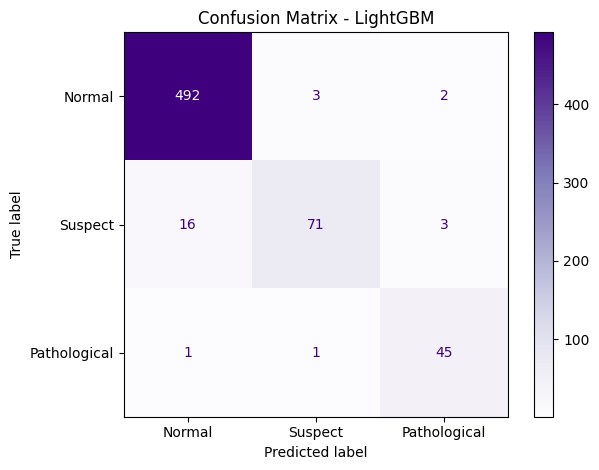


XGBoost


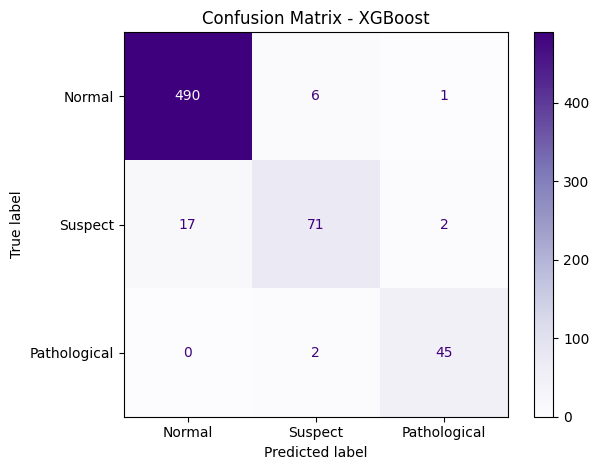


Gradient Boosting


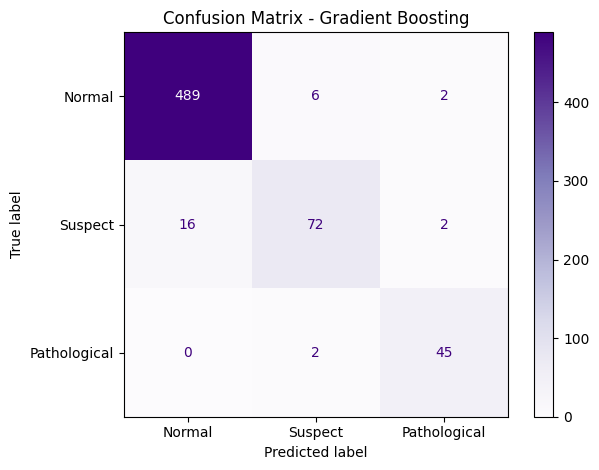


Multi-Layer Perceptron


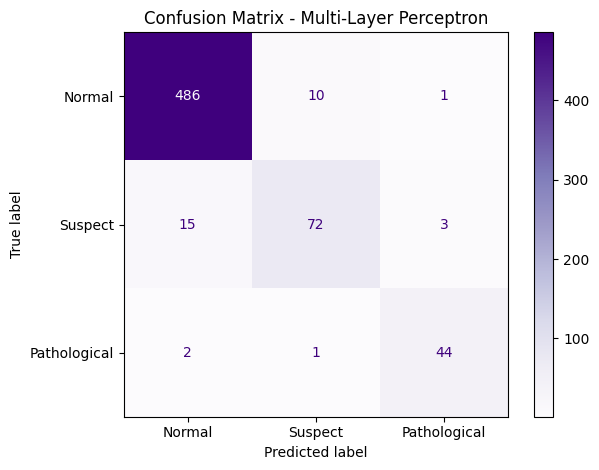


Linear Support Vector


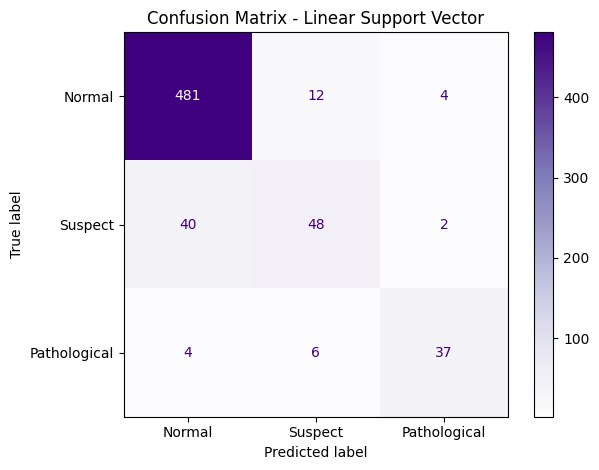

In [ ]:
for model_name in results_df["Model"]:

    print("\n", "=" * 60)
    print(model_name)
    print("=" * 60)

    cm = confusion_matrix(
        y_test,
        predictions[model_name]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Normal",
            "Suspect",
            "Pathological"
        ]
    )

    disp.plot(
        values_format="d",
        cmap="Purples"
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.tight_layout()
    plt.show()

Highest test accuracy: LightGBM


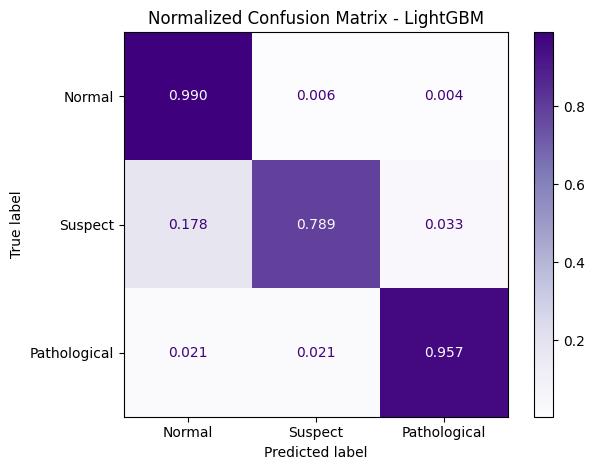

In [ ]:
best_model_name = results_df.iloc[0]["Model"]

best_predictions = predictions[
    best_model_name
]

print("Highest test accuracy:", best_model_name)

cm_normalized = confusion_matrix(
    y_test,
    best_predictions,
    normalize="true"
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=[
        "Normal",
        "Suspect",
        "Pathological"
    ]
)

disp.plot(
    values_format=".3f",
    cmap="Purples"
)

plt.title(
    f"Normalized Confusion Matrix - {best_model_name}"
)

plt.tight_layout()
plt.show()

## Comparison with the Reference Paper

The reproduced model scores can be compared with the results reported in
the reference paper.

Exact scores are not expected to be identical because the paper does not
fully specify the random train-test split seed or all model
hyperparameters.

In [ ]:
paper_scores = {
    "Gradient Boosting": 95.5836,
    "LightGBM": 95.5836,
    "XGBoost": 94.9527,
    "Multi-Layer Perceptron": 93.5331,
    "Linear Support Vector": 89.2744
}

comparison_df = results_df[
    ["Model", "Accuracy"]
].copy()

comparison_df["Reimplementation Accuracy (%)"] = (
    comparison_df["Accuracy"] * 100
)

comparison_df["Paper Accuracy (%)"] = (
    comparison_df["Model"].map(paper_scores)
)

# Difference in percentage points
comparison_df["Difference (pp)"] = (
    comparison_df["Reimplementation Accuracy (%)"]
    - comparison_df["Paper Accuracy (%)"]
)

comparison_df = comparison_df[
    [
        "Model",
        "Reimplementation Accuracy (%)",
        "Paper Accuracy (%)",
        "Difference (pp)"
    ]
]

comparison_df[
    [
        "Reimplementation Accuracy (%)",
        "Paper Accuracy (%)",
        "Difference (pp)"
    ]
] = comparison_df[
    [
        "Reimplementation Accuracy (%)",
        "Paper Accuracy (%)",
        "Difference (pp)"
    ]
].round(2)

comparison_df

,Model,Reimplementation Accuracy (%),Paper Accuracy (%),Difference (pp)
0,LightGBM,95.90,95.58,0.32
1,XGBoost,95.58,94.95,0.63
2,Gradient Boosting,95.58,95.58,-0.00
3,Multi-Layer Perceptron,94.95,93.53,1.42
4,Linear Support Vector,89.27,89.27,0.00


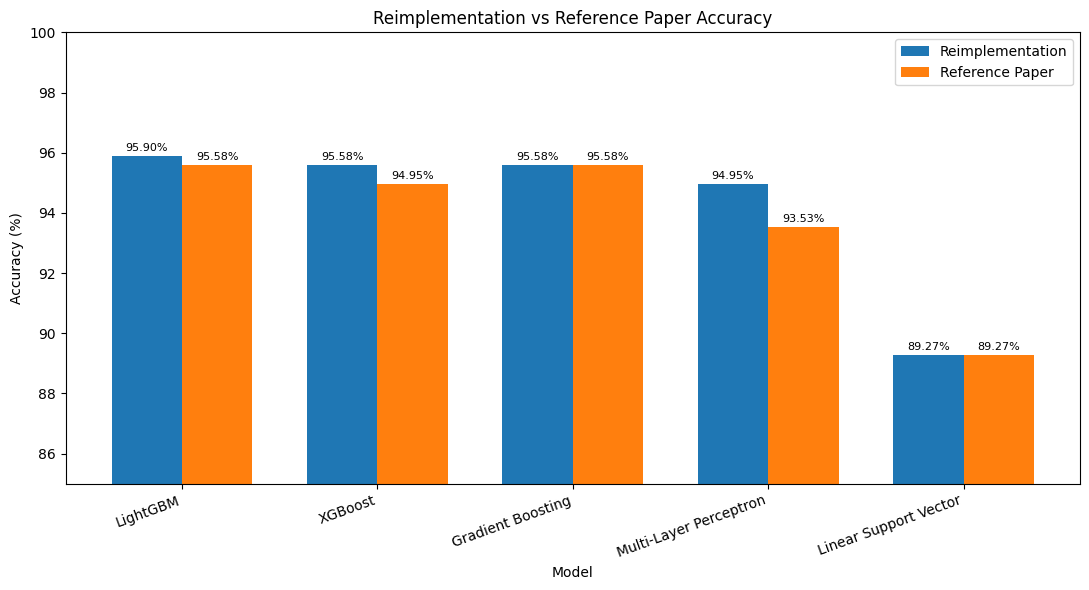

In [ ]:
comparison_plot = comparison_df.copy()

x = np.arange(len(comparison_plot))
width = 0.36

plt.figure(figsize=(11, 6))

bars1 = plt.bar(
    x - width / 2,
    comparison_plot["Reimplementation Accuracy (%)"],
    width,
    label="Reimplementation",
    color="#1f77b4"
)

bars2 = plt.bar(
    x + width / 2,
    comparison_plot["Paper Accuracy (%)"],
    width,
    label="Reference Paper",
    color="#ff7f0e"
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Reimplementation vs Reference Paper Accuracy")

plt.xticks(
    x,
    comparison_plot["Model"],
    rotation=20,
    ha="right"
)

plt.ylim(85, 100)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.1,
            f"{height:.2f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()
plt.show()

### Comparison with the Reference Paper

The reproduced results closely align with the accuracies reported in the
reference paper.

Gradient Boosting reproduced the reported accuracy almost exactly at
95.58%, while Linear SVM also matched the reported value of approximately
89.27%.

LightGBM achieved 95.90% accuracy in the reimplementation compared with
95.58% in the reference paper, a difference of approximately 0.32
percentage points.

XGBoost achieved 95.58%, approximately 0.63 percentage points higher
than the 94.95% reported in the paper.

The largest difference was observed for the Multi-Layer Perceptron,
which achieved 94.95% accuracy compared with 93.53% in the reference
paper, an increase of approximately 1.42 percentage points.

These small differences are reasonable because the reference paper does
not specify all model hyperparameters or the random seed used for the
70/30 train-test split. Consequently, an exact replication of every
reported score is not expected.

In [36]:
results_df.to_csv(
    "mlp_gradboosting_xgboost_lightgbm_linear_svm_results.csv",
    index=False
)

print("Results exported successfully.")

Results exported successfully.
